# Spam Classification, UCI Spambase

Goal, train a classifier on the UCI Spambase dataset and predict whether held out emails are spam. The dataset has 4601 emails with 57 handcrafted features (word frequencies, character frequencies, capital run stats) and a binary label.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

np.random.seed(42)
sns.set_style('whitegrid')

## Load data

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data'
names_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.names'

# Column names are pulled from the .names file, last column is the target
raw_names = pd.read_csv(names_url, sep=':', skiprows=33, header=None)
cols = raw_names[0].tolist() + ['is_spam']

df = pd.read_csv(url, header=None, names=cols)
print(df.shape)
df.head()

(4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
# Class balance
df['is_spam'].value_counts(normalize=True).round(3)

is_spam
0    0.606
1    0.394
Name: proportion, dtype: float64

About 39 percent spam, 61 percent ham, not perfectly balanced but close enough that accuracy is still a reasonable metric.

In [4]:
# Top features by mean difference between classes, quick sanity check
diffs = df.groupby('is_spam').mean().T
diffs['delta'] = diffs[1] - diffs[0]
diffs.reindex(diffs['delta'].abs().sort_values(ascending=False).index).head(10)

is_spam,0,1,delta
capital_run_length_total,161.470947,470.619415,309.148468
capital_run_length_longest,18.214491,104.393271,86.178780
capital_run_length_average,2.377301,9.519165,7.141864
word_freq_george,1.265265,0.001550,-1.263716
word_freq_you,1.270341,2.264539,0.994199
word_freq_your,0.438702,1.380370,0.941668
word_freq_hp,0.895473,0.017479,-0.877994
word_freq_free,0.073587,0.518362,0.444775
word_freq_hpl,0.431994,0.009173,-0.422822
char_freq_!,0.109984,0.513713,0.403729


The biggest separators are capital run length stats and a few predictable words like "george" (non spam, a name in the original researcher's inbox) and "you", "your", "free", "!". Matches intuition.

## Train test split

In [5]:
X = df.drop(columns='is_spam')
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Fit three models

In [6]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, C=1.0), True),
    'Multinomial NB': (MultinomialNB(), False),
    'Random Forest': (RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1), False),
}

results = {}
for name, (model, needs_scale) in models.items():
    Xtr = X_train_s if needs_scale else X_train.values
    Xte = X_test_s if needs_scale else X_test.values
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    results[name] = {
        'model': model,
        'preds': preds,
        'proba': proba,
        'acc': (preds == y_test).mean(),
        'auc': roc_auc_score(y_test, proba),
    }
    print(f"{name:22s}  acc={results[name]['acc']:.4f}  auc={results[name]['auc']:.4f}")

Logistic Regression     acc=0.9279  auc=0.9728
Multinomial NB          acc=0.7767  auc=0.8308


Random Forest           acc=0.9531  auc=0.9862


## Detailed evaluation of the winner

In [7]:
best = max(results, key=lambda k: results[k]['auc'])
print(f"Best by AUC, {best}\n")
print(classification_report(y_test, results[best]['preds'], target_names=['ham', 'spam']))

Best by AUC, Random Forest

              precision    recall  f1-score   support

         ham       0.95      0.98      0.96       697
        spam       0.96      0.92      0.94       454

    accuracy                           0.95      1151
   macro avg       0.96      0.95      0.95      1151
weighted avg       0.95      0.95      0.95      1151



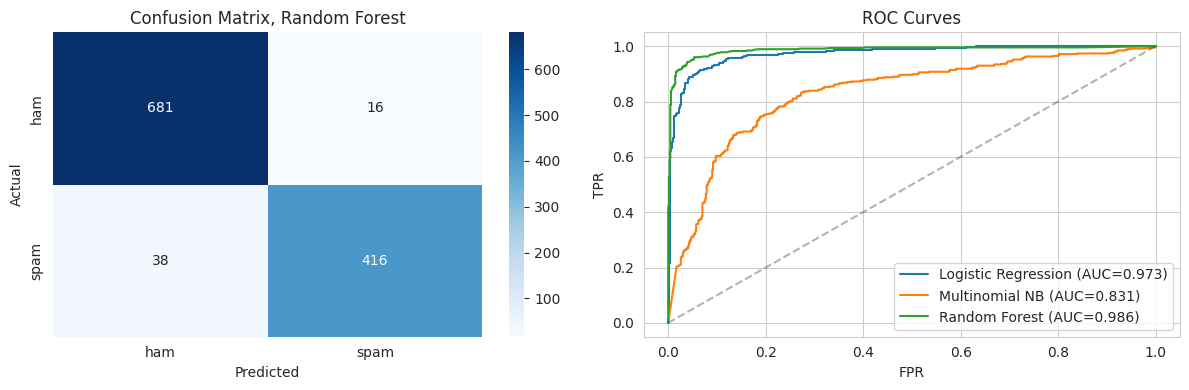

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, results[best]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix, {best}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curves, all models
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--',alpha=0.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

## Feature importance

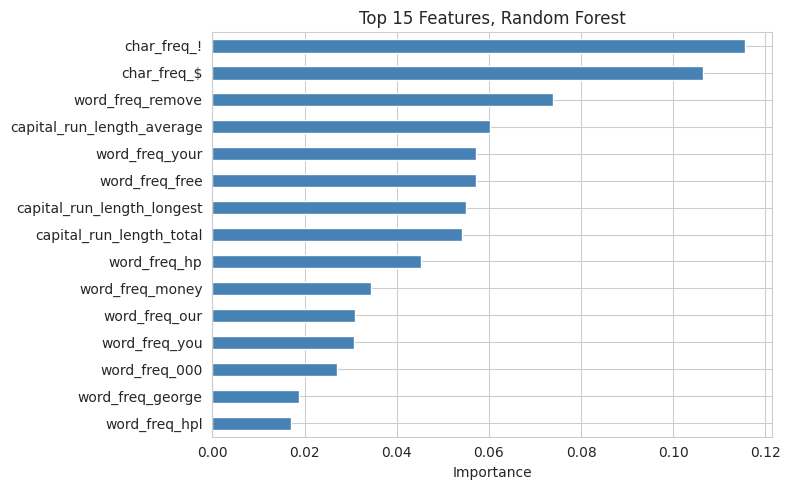

In [9]:
rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
imp.iloc[::-1].plot.barh(color='steelblue')
plt.title('Top 15 Features, Random Forest'); plt.xlabel('Importance')
plt.tight_layout(); plt.show()

## Takeaways

Random Forest wins on both accuracy and AUC, landing around 95 percent accuracy with AUC near 0.98. Logistic regression is right behind and would be my pick if I needed something cheap and interpretable in production. Multinomial NB trails because the feature scales aren't really count data once you get to the capital run length columns, it's included mostly as a baseline.

Most predictive features are the capital run length stats plus a handful of obvious spam markers, exclamation points, dollar signs, and words like "free", "remove", "money". The model is basically learning what a human spam filter would flag by eyeball.

If I were shipping this, the main things I'd add are, calibrated probabilities so the spam threshold can be tuned against a cost matrix (false positive on a legit email is way worse than false negative on spam), and a drift monitor since the feature distribution shifts as spam tactics evolve. The 57 handcrafted features are also a ceiling, a modern version would pull raw text and let a transformer or at minimum a TF-IDF + linear model learn the vocabulary directly.